In [13]:
# pip install torch transformers pillow numpy

from pathlib import Path
import json
import numpy as np
import torch
from PIL import Image
from transformers import AutoProcessor, RTDetrForObjectDetection, VitPoseForPoseEstimation
from time import perf_counter

def sync_device():
    if device == "cuda":
        torch.cuda.synchronize()

inference_times = []
INPUT_DIR = Path("/Users/buithianhdao/job/mediapipe_testing/Subject1Activity1Trial1Camera1")
OUT_JSON = Path("/Users/buithianhdao/job/mediapipe_testing/vitpose_outputs/pose_result.json")

device = "cuda" if torch.cuda.is_available() else "cpu"

# 1. Detector người
det_processor = AutoProcessor.from_pretrained("PekingU/rtdetr_r50vd_coco_o365")
det_model = RTDetrForObjectDetection.from_pretrained("PekingU/rtdetr_r50vd_coco_o365").to(device).eval()

# 2. ViTPose
pose_processor = AutoProcessor.from_pretrained("usyd-community/vitpose-base-simple")
pose_model = VitPoseForPoseEstimation.from_pretrained("usyd-community/vitpose-base-simple").to(device).eval()

results_all = []

for img_path in sorted(INPUT_DIR.glob("*.png")):
    image = Image.open(img_path).convert("RGB")
    sync_device()
    start_time = perf_counter()
    # Detect human boxes: output ban đầu là xyxy
    inputs = det_processor(images=image, return_tensors="pt").to(device)
    with torch.no_grad():
        det_outputs = det_model(**inputs)

    det_results = det_processor.post_process_object_detection(
        det_outputs,
        target_sizes=torch.tensor([(image.height, image.width)], device=device),
        threshold=0.3,
    )[0]

    # COCO person label = 0
    boxes_xyxy = det_results["boxes"][det_results["labels"] == 0].detach().cpu().numpy()

    item = {"image": img_path.name, "persons": []}

    if len(boxes_xyxy) > 0:
        # ViTPose cần box format COCO: x, y, w, h
        boxes_xywh = boxes_xyxy.copy()
        boxes_xywh[:, 2] = boxes_xywh[:, 2] - boxes_xywh[:, 0]
        boxes_xywh[:, 3] = boxes_xywh[:, 3] - boxes_xywh[:, 1]

        pose_inputs = pose_processor(image, boxes=[boxes_xywh], return_tensors="pt").to(device)
        with torch.no_grad():
            pose_outputs = pose_model(**pose_inputs)

        pose_results = pose_processor.post_process_pose_estimation(
            pose_outputs,
            boxes=[boxes_xywh],
        )[0]

        for person_id, pose in enumerate(pose_results):
            item["persons"].append({
                "person_id": person_id,
                "bbox_xywh": boxes_xywh[person_id].tolist(),
                "keypoints": pose["keypoints"].detach().cpu().numpy().tolist(),
                "scores": pose["scores"].detach().cpu().numpy().tolist(),
            })
    sync_device()
    inference_times.append(perf_counter() - start_time)
    results_all.append(item)
if inference_times:
    inference_times = np.asarray(inference_times, dtype=float)
    avg_time = inference_times.mean()

    print(f"Processed {len(inference_times)} images on {device}")
    print(f"Average inference time: {avg_time:.4f} s/image ({1 / avg_time:.2f} FPS)")
    print(
        f"Median: {np.median(inference_times):.4f}s | "
        f"Min: {inference_times.min():.4f}s | "
        f"Max: {inference_times.max():.4f}s"
    )
OUT_JSON.parent.mkdir(parents=True, exist_ok=True)
OUT_JSON.write_text(json.dumps(results_all, indent=2), encoding="utf-8")
OUT_JSON


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6463.97it/s]


Processed 195 images on cpu
Average inference time: 0.5922 s/image (1.69 FPS)
Median: 0.5679s | Min: 0.4896s | Max: 3.2043s


PosixPath('/Users/buithianhdao/job/mediapipe_testing/vitpose_outputs/pose_result.json')

Saved 195 images to /Users/buithianhdao/job/mediapipe_testing/vitpose_outputs/drawn_images


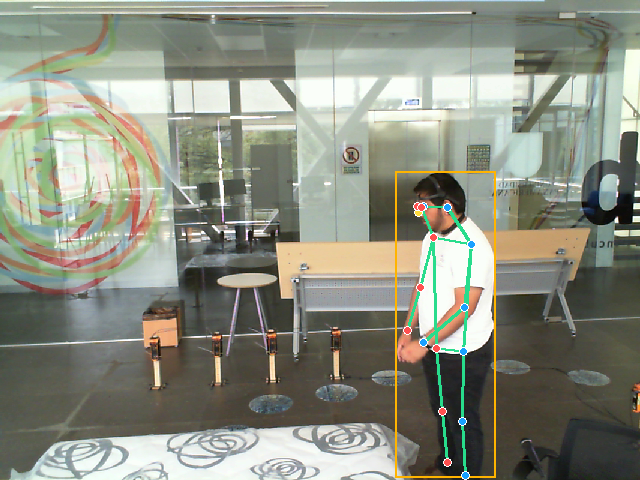

In [12]:
from pathlib import Path
import json
import numpy as np
from PIL import Image, ImageDraw
from IPython.display import display

INPUT_DIR = Path("/Users/buithianhdao/job/mediapipe_testing/Subject1Activity1Trial1Camera1")
POSE_JSON = Path("/Users/buithianhdao/job/mediapipe_testing/vitpose_outputs/pose_result.json")
OUT_DIR = Path("/Users/buithianhdao/job/mediapipe_testing/vitpose_outputs/drawn_images")

KPT_THR = 0.3

COCO_EDGES = [
    (5, 7), (7, 9),
    (6, 8), (8, 10),
    (5, 6),
    (5, 11), (6, 12),
    (11, 12),
    (11, 13), (13, 15),
    (12, 14), (14, 16),
    (0, 1), (0, 2),
    (1, 3), (2, 4),
    (3, 5), (4, 6),
]

LEFT_KEYPOINTS = {1, 3, 5, 7, 9, 11, 13, 15}
RIGHT_KEYPOINTS = {2, 4, 6, 8, 10, 12, 14, 16}


def keypoint_color(idx):
    if idx in LEFT_KEYPOINTS:
        return (25, 160, 255)
    if idx in RIGHT_KEYPOINTS:
        return (255, 80, 80)
    return (255, 220, 60)


def draw_pose(image, persons, kpt_thr=0.3):
    canvas = image.copy()
    draw = ImageDraw.Draw(canvas)

    for person in persons:
        bbox = person.get("bbox_xywh")
        if bbox:
            x, y, w, h = map(float, bbox)
            draw.rectangle((x, y, x + w, y + h), outline=(255, 180, 0), width=2)

        keypoints = np.asarray(person.get("keypoints", []), dtype=float)
        scores = np.asarray(person.get("scores", []), dtype=float)

        if len(keypoints) == 0:
            continue

        for a, b in COCO_EDGES:
            if a >= len(keypoints) or b >= len(keypoints):
                continue
            if scores[a] < kpt_thr or scores[b] < kpt_thr:
                continue

            x1, y1 = keypoints[a]
            x2, y2 = keypoints[b]
            draw.line((x1, y1, x2, y2), fill=(40, 220, 140), width=3)

        for idx, (x, y) in enumerate(keypoints):
            if idx >= len(scores) or scores[idx] < kpt_thr:
                continue

            r = 4
            color = keypoint_color(idx)
            draw.ellipse((x - r, y - r, x + r, y + r), fill=color, outline=(255, 255, 255))

    return canvas


pose_items = json.loads(POSE_JSON.read_text(encoding="utf-8"))
OUT_DIR.mkdir(parents=True, exist_ok=True)

saved_paths = []

for item in pose_items:
    img_path = INPUT_DIR / item["image"]

    if not img_path.exists():
        print("Missing:", img_path)
        continue

    image = Image.open(img_path).convert("RGB")
    annotated = draw_pose(image, item.get("persons", []), KPT_THR)

    out_path = OUT_DIR / f"pose_{img_path.name}"
    annotated.save(out_path)
    saved_paths.append(out_path)

print(f"Saved {len(saved_paths)} images to {OUT_DIR}")

if saved_paths:
    display(Image.open(saved_paths[0]))
